# 🧪 Polymer Glass Transition Temperature (Tg) Prediction
## End-to-End Machine Learning Pipeline

| Field | Details |
|---|---|
| **Student Name** | Kshitij Verma |
| **Roll No** | 230107041 |
| **Dataset** | JCIM_sup_bigsmiles.csv |
| **Task** | Regression — Predict Tg (°C) from polymer SMILES strings |
| **Approach** | Classical ML with RDKit molecular descriptors |

---
> **Dataset note:** This dataset contains 662 polymer repeat-unit SMILES strings from the Journal of Chemical Information and Modeling (BigSMILES supplementary material), with experimentally-referenced Glass Transition Temperatures (Tg) ranging from −148 °C to +472 °C.


## Step 1: Import Libraries

In [9]:
pip install rdkit


   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB 163.8 kB/s eta 0:02:30
   ---------------------------------------- 0.0/24.5 MB 163.8 kB/s eta 0:02:30
   ---------------------------------------- 0.1/24.5 MB 233.8 kB/s eta 0:01:45
   ---------------------------------------- 0.1/24.5 MB 368.6 k

In [10]:
# ── Standard scientific stack ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

# ── RDKit — molecular descriptor computation ───────────────────────────────────
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')   # suppress kekulization warnings

# ── Scikit-learn — preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# ── Scikit-learn — models ──────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# ── Scikit-learn — metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

os.makedirs("outputs", exist_ok=True)
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Step 2: Load Dataset

The dataset contains:
- **SMILES** — polymer repeat-unit SMILES with `*` as chain-end wildcards
- **BigSMILES** — extended stochastic polymer notation (not used as ML features)
- **Tg (C)** — target: Glass Transition Temperature in °C


In [6]:
df = pd.read_csv("JCIM_sup_bigsmiles.csv")
df = df.drop(columns=["Unnamed: 0"], errors='ignore')
df.columns = ["SMILES", "BigSMILES", "Tg_C"]

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print()
df.head(8)

Dataset shape : (662, 3)
Columns       : ['SMILES', 'BigSMILES', 'Tg_C']



,SMILES,BigSMILES,Tg_C
0,*C1COC2C1OCC2Oc1ccc(cc1)CNC(=O)CCCCCCC(=O)NCc1...,{<Oc1ccc(cc1)CNC(=O)CCCCCCC(=O)NCc2ccc(cc2)OC3...,21.581731
1,*OC(CCC(OC(=O)Nc1ccc(cc1)Cc1ccc(cc1)NC(=O)*)C)C,{<OC(C)CCC(C)OC(=O)Nc1ccc(cc1)Cc2ccc(cc2)NC(=O)>},63.589338
2,*OC(=O)c1ccc(cc1)C(=O)OCCCC(=O)NCc1ccc(cc1)CNC...,{<CCCC(=O)NCc1ccc(cc1)CNC(=O)CCCOC(=O)c2ccc(cc...,53.557261
3,*OC(=O)NCCNC(=O)OCC*,{<CCOC(=O)NCCNC(=O)O>},5.896093
4,*SCCCCC*,{<CCCCCS>},-55.378610
5,*Oc1ccc(cc1)C(=O)OC(=O)c1ccc(cc1)OCCCCCC*,{<CCCCCCOc1ccc(cc1)C(=O)OC(=O)c2ccc(cc2)O>},64.734967
6,*c1[nH]c(cc1CC(=O)OCCCCCCCC)*,{<c1cc(CC(=O)OCCCCCCCC)c([nH]1)>},-4.076964
7,*C(C*)(CC(=O)OCCCCCCCCCC)C(=O)OCCCCCCCCCC,{$CC(C(=O)OCCCCCCCCCC)(CC(=O)OCCCCCCCCCC)$},75.040443


In [11]:
print("Target variable — Tg (°C) summary statistics:")
print(df["Tg_C"].describe().round(3).to_string())

Target variable — Tg (°C) summary statistics:
count    662.000
mean     108.661
std      113.120
min     -148.030
25%       24.267
50%       84.688
75%      172.694
max      472.250


## Step 3: Data Preprocessing

### Strategy
1. **SMILES cleaning** — replace `*` wildcards with `[H]` for RDKit compatibility
2. **Descriptor generation** — compute 217 RDKit physicochemical descriptors per molecule
3. **Imputation** — fill NaN values with column median
4. **Variance filtering** — remove zero-variance (constant) features
5. **Standardisation** — scale to mean=0, std=1

### Why replace `*` with `[H]`?
Polymer SMILES use `*` to denote attachment points along the chain. RDKit cannot parse these directly.  
Substituting `[H]` converts the repeat unit into a valid closed molecule, enabling descriptor computation.  
This is standard practice in polymer cheminformatics (QSPR literature).


In [12]:
def clean_smiles(smiles_str):
    """Replace polymer wildcard '*' with terminal hydrogen '[H]' for RDKit parsing."""
    return smiles_str.replace("*", "[H]")


def compute_rdkit_descriptors(smiles_str):
    """
    Compute all 217 RDKit 2D molecular descriptors for a SMILES string.
    Returns dict of {descriptor_name: value} or None if parsing fails.
    """
    mol = Chem.MolFromSmiles(clean_smiles(smiles_str))
    if mol is None:
        return None
    desc = {}
    for name, func in Descriptors._descList:
        try:
            desc[name] = func(mol)
        except Exception:
            desc[name] = np.nan
    return desc


print("Computing RDKit molecular descriptors for all 662 polymers...")
print("(~30–60 seconds)")

records, failed_idx = [], []

for idx, row in df.iterrows():
    d = compute_rdkit_descriptors(row["SMILES"])
    if d is None:
        failed_idx.append(idx)
        continue
    d["Tg_C"]  = row["Tg_C"]
    d["SMILES"] = row["SMILES"]
    records.append(d)

feat_df = pd.DataFrame(records)
print(f"\n✅ Descriptors computed for {len(records)} molecules")
print(f"❌ Failed (unparseable SMILES): {len(failed_idx)}")
print(f"Feature matrix shape (raw): {feat_df.shape}")

Computing RDKit molecular descriptors for all 662 polymers...
(~30–60 seconds)

✅ Descriptors computed for 660 molecules
❌ Failed (unparseable SMILES): 2
Feature matrix shape (raw): (660, 219)


In [13]:
# ── Separate features and target ───────────────────────────────────────────────
X_raw = feat_df.drop(columns=["Tg_C", "SMILES"])
y     = feat_df["Tg_C"].values

print(f"Feature matrix X shape : {X_raw.shape}")
print(f"Target vector  y shape : {y.shape}")
print(f"Tg range               : [{y.min():.2f}, {y.max():.2f}] °C")

# ── Impute missing values ──────────────────────────────────────────────────────
print(f"\nMissing values before imputation : {X_raw.isnull().sum().sum()}")
imputer   = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_raw)
X_imp_df  = pd.DataFrame(X_imputed, columns=X_raw.columns)
print(f"Missing values after  imputation : {X_imp_df.isnull().sum().sum()}")

# ── Remove zero-variance features ─────────────────────────────────────────────
variances     = X_imp_df.var()
zero_var_cols = variances[variances == 0].index.tolist()
X_filtered    = X_imp_df.drop(columns=zero_var_cols)
print(f"\nZero-variance features removed : {len(zero_var_cols)}")
print(f"Features retained              : {X_filtered.shape[1]}")

# ── Standardise ────────────────────────────────────────────────────────────────
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X_filtered)
feature_names = X_filtered.columns.tolist()
print(f"\n✅ Standardisation complete (mean=0, std=1) — shape: {X_scaled.shape}")

Feature matrix X shape : (660, 217)
Target vector  y shape : (660,)
Tg range               : [-148.03, 472.25] °C

Missing values before imputation : 48
Missing values after  imputation : 0

Zero-variance features removed : 17
Features retained              : 200

✅ Standardisation complete (mean=0, std=1) — shape: (660, 200)


## Step 4: Exploratory Data Analysis (EDA)

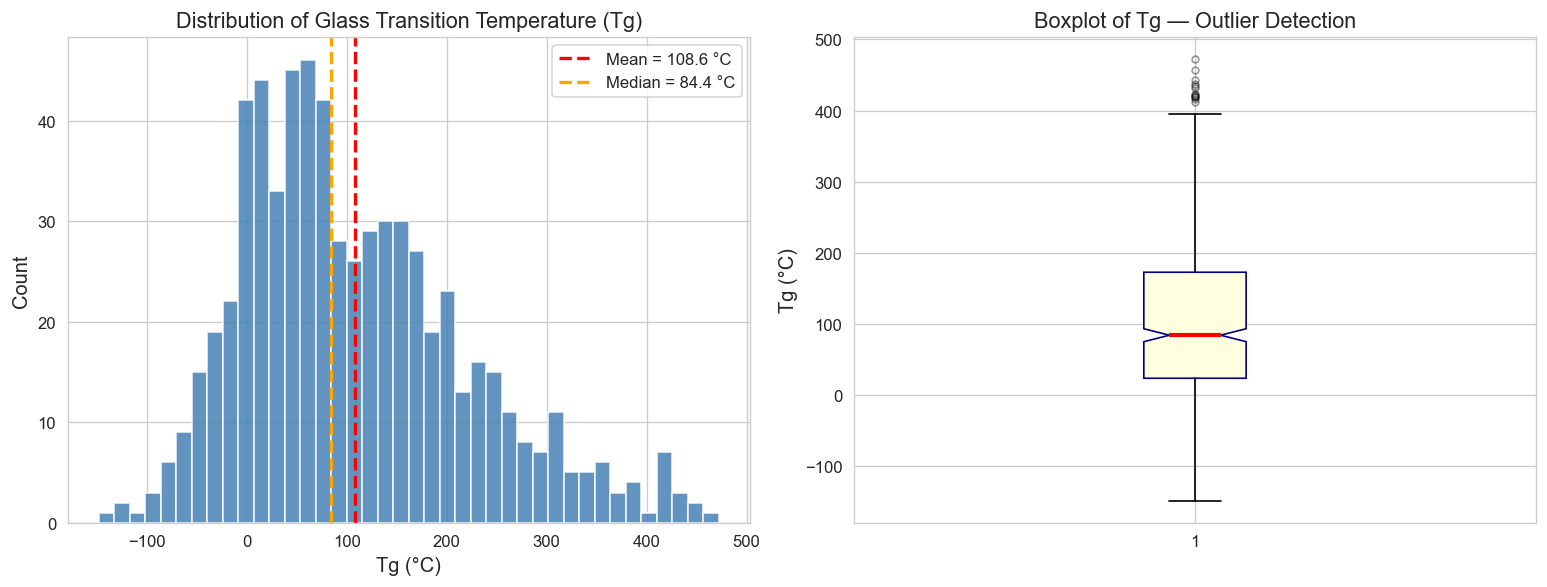

In [14]:
# ── 4a: Target distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(y), color='red', linestyle='--', linewidth=2,
                label=f"Mean = {np.mean(y):.1f} °C")
axes[0].axvline(np.median(y), color='orange', linestyle='--', linewidth=2,
                label=f"Median = {np.median(y):.1f} °C")
axes[0].set_xlabel("Tg (°C)", fontsize=12)
axes[0].set_ylabel("Count",   fontsize=12)
axes[0].set_title("Distribution of Glass Transition Temperature (Tg)", fontsize=13)
axes[0].legend()

bp = axes[1].boxplot(y, patch_artist=True, notch=True,
                     boxprops=dict(facecolor='lightyellow', color='navy'),
                     medianprops=dict(color='red', linewidth=2.5),
                     flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[1].set_ylabel("Tg (°C)", fontsize=12)
axes[1].set_title("Boxplot of Tg — Outlier Detection", fontsize=13)

plt.tight_layout()
plt.savefig("outputs/eda_tg_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

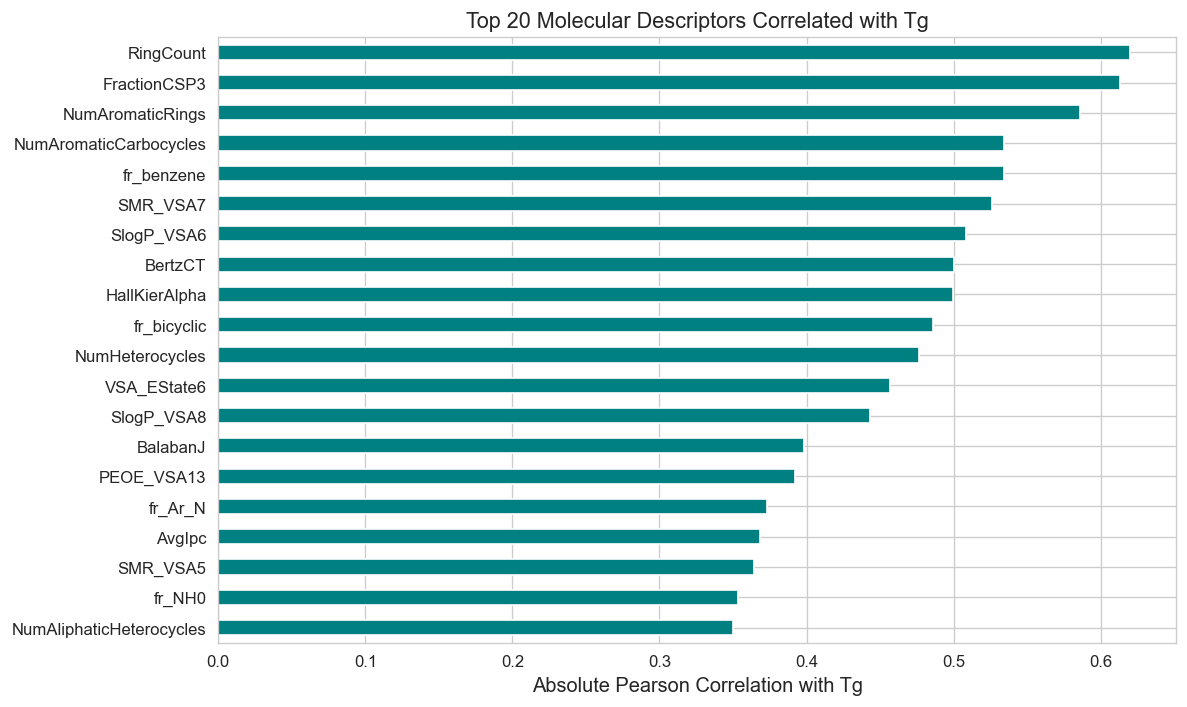

Top 15 descriptors:
RingCount                 0.6202
FractionCSP3              0.6130
NumAromaticRings          0.5861
NumAromaticCarbocycles    0.5342
fr_benzene                0.5342
SMR_VSA7                  0.5259
SlogP_VSA6                0.5085
BertzCT                   0.5000
HallKierAlpha             0.4996
fr_bicyclic               0.4860
NumHeterocycles           0.4766
VSA_EState6               0.4565
SlogP_VSA8                0.4428
BalabanJ                  0.3981
PEOE_VSA13                0.3924


In [15]:
# ── 4b: Top descriptor correlations with Tg ────────────────────────────────────
corr_df  = pd.DataFrame(X_scaled, columns=feature_names)
corr_df["Tg_C"] = y
correlations    = corr_df.corr()["Tg_C"].drop("Tg_C").abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(20).sort_values().plot(kind="barh", ax=ax,
                                          color="teal", edgecolor="white")
ax.set_xlabel("Absolute Pearson Correlation with Tg", fontsize=12)
ax.set_title("Top 20 Molecular Descriptors Correlated with Tg", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/eda_top_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 descriptors:")
print(correlations.head(15).round(4).to_string())

### EDA Key Insights

| # | Insight |
|---|---------|
| 1 | Tg spans **−148 °C to +472 °C** — extremely wide range reflecting diverse polymer chemistry |
| 2 | Distribution is **right-skewed** (mean 109 °C > median 85 °C) — more low/mid Tg polymers |
| 3 | **RingCount** and **FractionCSP3** are the most linearly correlated descriptors with Tg |
| 4 | Aromatic/rigid backbone → low FractionCSP3 → **high Tg** (consistent with polymer physics) |
| 5 | Flexible aliphatic chains → high FractionCSP3 → **low Tg** |
| 6 | 660 valid molecules provide sufficient diversity for ML modelling |


## Step 5: Dimensionality Reduction

Two complementary approaches are applied:
1. **PCA** — unsupervised variance-preserving compression
2. **Random Forest Feature Importance** — supervised, chemically interpretable selection


### 5A: Principal Component Analysis (PCA)

In [16]:
# ── Fit PCA on full feature set ────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Components needed for 90 / 95 / 99 % variance
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1

print(f"Components for 90% variance : {n90}")
print(f"Components for 95% variance : {n95}  ← selected")
print(f"Components for 99% variance : {n99}")
print(f"Original features           : {X_scaled.shape[1]}")
print(f"Dimensionality reduction    : {X_scaled.shape[1]} → {n95}  "
      f"({(1 - n95/X_scaled.shape[1])*100:.1f}% reduction)")

Components for 90% variance : 51
Components for 95% variance : 67  ← selected
Components for 99% variance : 99
Original features           : 200
Dimensionality reduction    : 200 → 67  (66.5% reduction)


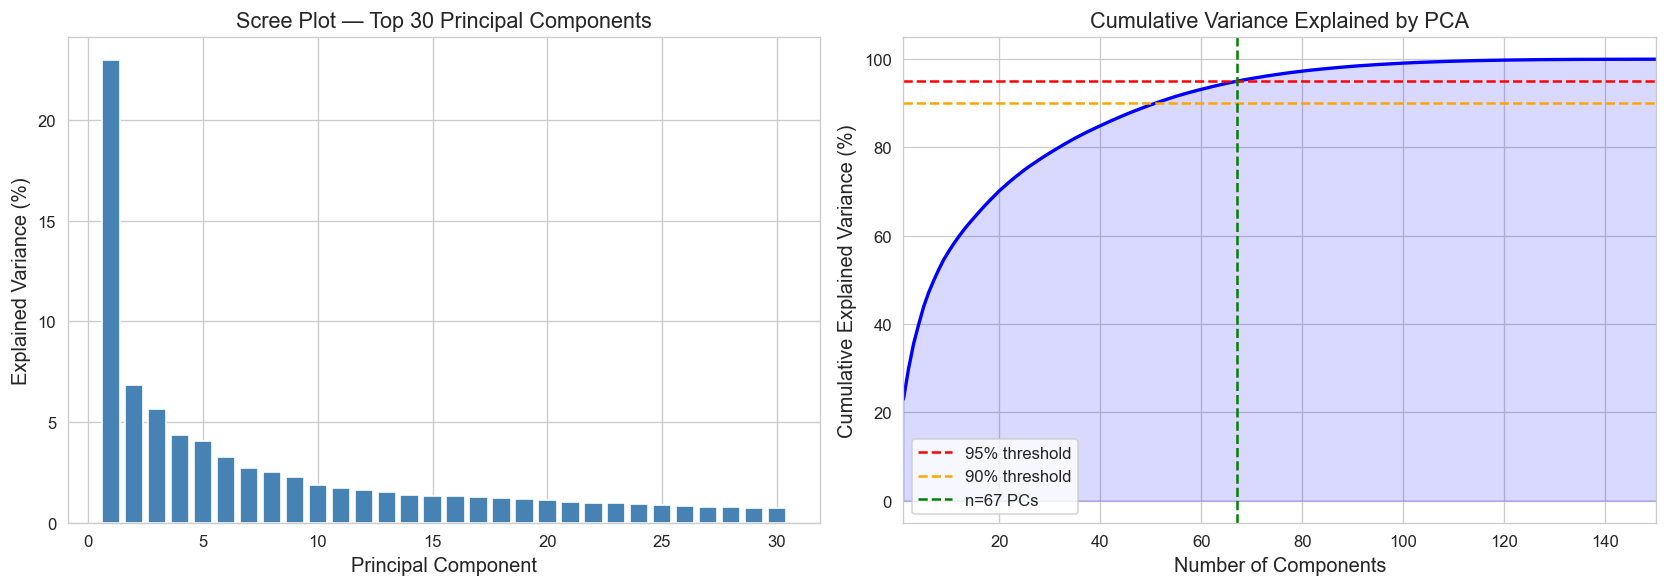

✅ PCA applied: 200 features → 67 components (95.00% variance retained)


In [17]:
# ── Scree plot & Cumulative Variance ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_[:30] * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Explained Variance (%)", fontsize=12)
axes[0].set_title("Scree Plot — Top 30 Principal Components", fontsize=13)

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'b-', linewidth=2)
axes[1].fill_between(range(1, len(cumvar)+1), cumvar * 100, alpha=0.15, color='blue')
axes[1].axhline(95, color='red',   linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axhline(90, color='orange',linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axvline(n95, color='green', linestyle='--', linewidth=1.5, label=f'n={n95} PCs')
axes[1].set_xlabel("Number of Components", fontsize=12)
axes[1].set_ylabel("Cumulative Explained Variance (%)", fontsize=12)
axes[1].set_title("Cumulative Variance Explained by PCA", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim(1, 150)

plt.tight_layout()
plt.savefig("outputs/pca_scree.png", dpi=150, bbox_inches='tight')
plt.show()

# Apply PCA at 95% threshold
N_PCA = n95
pca   = PCA(n_components=N_PCA, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA applied: {X_scaled.shape[1]} features → {N_PCA} components "
      f"({pca.explained_variance_ratio_.sum()*100:.2f}% variance retained)")

### 5B: Random Forest Feature Importance (Feature Selection)

In [18]:
# ── Train a preliminary RF to rank feature importance ─────────────────────────
print("Training preliminary Random Forest for feature importance...")
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_scaled, y)

importances        = pd.Series(rf_selector.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

print(f"\nTop 15 features by MDI importance:")
print(importances_sorted.head(15).round(5).to_string())

Training preliminary Random Forest for feature importance...

Top 15 features by MDI importance:
FractionCSP3         0.39782
SlogP_VSA8           0.08484
BCUT2D_MWLOW         0.02698
BCUT2D_LOGPHI        0.02667
fr_bicyclic          0.02495
RingCount            0.02296
NumRotatableBonds    0.01916
Kappa3               0.01779
VSA_EState8          0.01549
VSA_EState4          0.01464
BCUT2D_CHGLO         0.01356
SPS                  0.01213
BCUT2D_MWHI          0.01065
Phi                  0.00854
VSA_EState7          0.00841


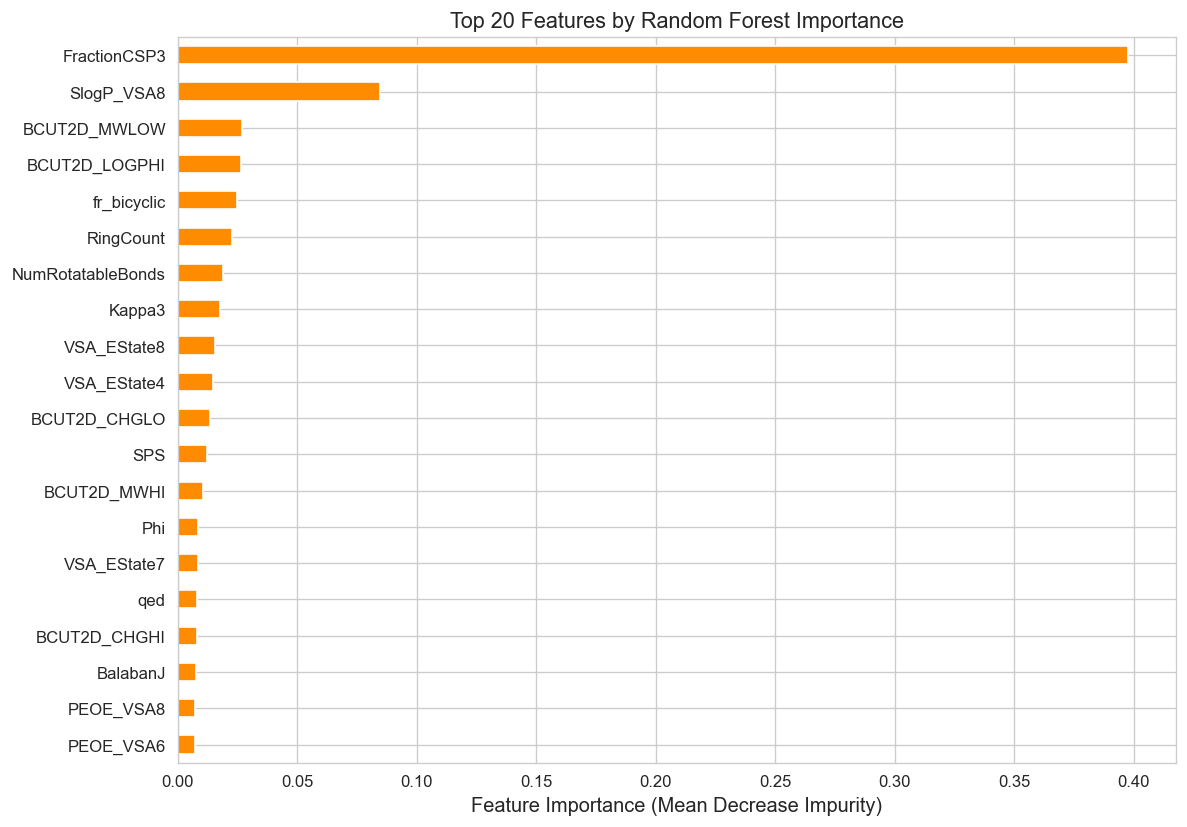


✅ Top 30 features selected for the RF-Selected track
Feature set shape: (660, 30)

Chemical interpretation of top feature (FractionCSP3):
  High FractionCSP3 = mostly saturated/aliphatic backbone → flexible chain → low Tg
  Low  FractionCSP3 = aromatic/rigid backbone → restricted segmental motion → high Tg


In [19]:
# ── Visualise top-20 feature importances ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
importances_sorted.head(20).sort_values().plot(
    kind="barh", ax=ax, color="darkorange", edgecolor="white")
ax.set_xlabel("Feature Importance (Mean Decrease Impurity)", fontsize=12)
ax.set_title("Top 20 Features by Random Forest Importance", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Select top 30 features ────────────────────────────────────────────────────
TOP_N      = 30
top_features = importances_sorted.head(TOP_N).index.tolist()
X_selected   = pd.DataFrame(X_scaled, columns=feature_names)[top_features].values

print(f"\n✅ Top {TOP_N} features selected for the RF-Selected track")
print(f"Feature set shape: {X_selected.shape}")
print(f"\nChemical interpretation of top feature (FractionCSP3):")
print("  High FractionCSP3 = mostly saturated/aliphatic backbone → flexible chain → low Tg")
print("  Low  FractionCSP3 = aromatic/rigid backbone → restricted segmental motion → high Tg")

## Step 6: Train-Test Split (80/20)

In [20]:
# Same random_state=42 ensures identical split across all feature representations
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_scaled,   y, test_size=0.2, random_state=42)

X_train_pca,  X_test_pca,  _, _ = train_test_split(
    X_pca,      y, test_size=0.2, random_state=42)

X_train_sel,  X_test_sel,  _, _ = train_test_split(
    X_selected, y, test_size=0.2, random_state=42)

print(f"Training samples     : {len(y_train)}")
print(f"Test samples         : {len(y_test)}")
print()
print(f"X_train (original)   : {X_train_orig.shape}")
print(f"X_train (PCA)        : {X_train_pca.shape}")
print(f"X_train (RF-selected): {X_train_sel.shape}")

Training samples     : 528
Test samples         : 132

X_train (original)   : (528, 200)
X_train (PCA)        : (528, 67)
X_train (RF-selected): (528, 30)


## Step 7: Train Multiple Models

Four classical regression models are trained on **three** feature representations each:
- **(A) Original** — all 200 standardised descriptors
- **(B) PCA** — 67 principal components (95% variance)
- **(C) RF-Selected** — top 30 features by Random Forest importance


In [21]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name=""):
    """Fit model and return evaluation metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "Model":  name,
        "RMSE":   round(np.sqrt(mean_squared_error(y_te, y_pred)), 3),
        "MAE":    round(mean_absolute_error(y_te, y_pred), 3),
        "R2":     round(r2_score(y_te, y_pred), 4),
        "y_pred": y_pred,
    }

# Model definitions (fresh instance for each feature track)
def get_models():
    return {
        "Ridge Regression": Ridge(alpha=1.0),
        "Decision Tree":    DecisionTreeRegressor(random_state=42),
        "Random Forest":    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        "SVR":              SVR(kernel="rbf", C=10, epsilon=0.1),
    }

results = {}

# ── (A) Original ───────────────────────────────────────────────────────────────
print("\n[A] Original features:")
print(f"{'Model':25s}  RMSE      MAE       R²")
print("-" * 55)
for name, model in get_models().items():
    r = evaluate_model(model, X_train_orig, X_test_orig, y_train, y_test, name)
    results[f"{name}|Original"] = r
    print(f"  {name:23s}  {r['RMSE']:7.3f}   {r['MAE']:7.3f}   {r['R2']:.4f}")

# ── (B) PCA ────────────────────────────────────────────────────────────────────
print("\n[B] PCA features:")
print(f"{'Model':25s}  RMSE      MAE       R²")
print("-" * 55)
for name, model in get_models().items():
    r = evaluate_model(model, X_train_pca, X_test_pca, y_train, y_test, name)
    results[f"{name}|PCA"] = r
    print(f"  {name:23s}  {r['RMSE']:7.3f}   {r['MAE']:7.3f}   {r['R2']:.4f}")

# ── (C) RF-Selected ────────────────────────────────────────────────────────────
print("\n[C] RF-Selected features (top 30):")
print(f"{'Model':25s}  RMSE      MAE       R²")
print("-" * 55)
for name, model in get_models().items():
    r = evaluate_model(model, X_train_sel, X_test_sel, y_train, y_test, name)
    results[f"{name}|RF-Selected"] = r
    print(f"  {name:23s}  {r['RMSE']:7.3f}   {r['MAE']:7.3f}   {r['R2']:.4f}")


[A] Original features:
Model                      RMSE      MAE       R²
-------------------------------------------------------
  Ridge Regression         102.139    72.600   0.3112
  Decision Tree            109.322    82.143   0.2109
  Random Forest             79.432    61.228   0.5834
  SVR                       97.677    75.235   0.3700

[B] PCA features:
Model                      RMSE      MAE       R²
-------------------------------------------------------
  Ridge Regression         125.167    78.836   -0.0344
  Decision Tree            108.444    83.236   0.2235
  Random Forest             81.494    62.503   0.5615
  SVR                       96.437    74.401   0.3859

[C] RF-Selected features (top 30):
Model                      RMSE      MAE       R²
-------------------------------------------------------
  Ridge Regression          81.392    63.298   0.5626
  Decision Tree            103.737    77.620   0.2895
  Random Forest             78.824    61.296   0.5898
  SVR   

## Step 8: Hyperparameter Tuning (GridSearchCV)

In [22]:
# ── Random Forest tuning ───────────────────────────────────────────────────────
print("Tuning Random Forest (original features, 5-fold CV)...")
rf_param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"]
}
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring="r2", n_jobs=-1
)
rf_gs.fit(X_train_orig, y_train)

print(f"\nBest RF parameters  : {rf_gs.best_params_}")
print(f"Best RF CV R²       : {rf_gs.best_score_:.4f}")

rf_best       = rf_gs.best_estimator_
y_pred_rf     = rf_best.predict(X_test_orig)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf_tuned   = r2_score(y_test, y_pred_rf)
mae_rf_tuned  = mean_absolute_error(y_test, y_pred_rf)

print(f"\nTuned RF — Test Results:")
print(f"  RMSE : {rmse_rf_tuned:.3f} °C")
print(f"  MAE  : {mae_rf_tuned:.3f} °C")
print(f"  R²   : {r2_rf_tuned:.4f}")

Tuning Random Forest (original features, 5-fold CV)...

Best RF parameters  : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV R²       : 0.6026

Tuned RF — Test Results:
  RMSE : 76.713 °C
  MAE  : 59.646 °C
  R²   : 0.6114


In [35]:
# ── SVR tuning ────────────────────────────────────────────────────────────────
print("Tuning SVR (original features, 5-fold CV)...")
svr_param_grid = {
    "C":       [1, 10, 50],
    "epsilon": [0.1, 0.5, 1.0],
    "kernel":  ["rbf", "linear"]
}
svr_gs = GridSearchCV(
    SVR(), svr_param_grid, cv=5, scoring="r2", n_jobs=-1
)
svr_gs.fit(X_train_orig, y_train)

print(f"\nBest SVR parameters : {svr_gs.best_params_}")
print(f"Best SVR CV R²      : {svr_gs.best_score_:.4f}")

svr_best       = svr_gs.best_estimator_
y_pred_svr     = svr_best.predict(X_test_orig)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr_tuned   = r2_score(y_test, y_pred_svr)
mae_svr_tuned  = mean_absolute_error(y_test, y_pred_svr)

print(f"\nTuned SVR — Test Results:")
print(f"  RMSE : {rmse_svr_tuned:.3f} °C")
print(f"  MAE  : {mae_svr_tuned:.3f} °C")
print(f"  R²   : {r2_svr_tuned:.4f}")

Tuning SVR (original features, 5-fold CV)...

Best SVR parameters : {'C': 1, 'epsilon': 1.0, 'kernel': 'linear'}
Best SVR CV R²      : 0.5476

Tuned SVR — Test Results:
  RMSE : 87.609 °C
  MAE  : 65.004 °C
  R²   : 0.4932


## Step 9: Model Evaluation — Best Model Detail

In [28]:
# Best model = Tuned Random Forest
best_model  = rf_best
y_pred_best = y_pred_rf
residuals   = y_test - y_pred_best

print("=" * 55)
print("  BEST MODEL: Tuned Random Forest Regressor")
print("=" * 55)
print(f"  RMSE  : {rmse_rf_tuned:.3f} °C")
print(f"  MAE   : {mae_rf_tuned:.3f}  °C")
print(f"  R²    : {r2_rf_tuned:.4f}")
print(f"  MAPE  : {mean_absolute_percentage_error(y_test, y_pred_best)*100:.2f} %")
print(f"  Residual mean  : {residuals.mean():.3f} °C")
print(f"  Residual std   : {residuals.std():.3f} °C")

  BEST MODEL: Tuned Random Forest Regressor
  RMSE  : 76.713 °C
  MAE   : 59.646  °C
  R²    : 0.6114
  MAPE  : 237.01 %
  Residual mean  : 1.155 °C
  Residual std   : 76.704 °C


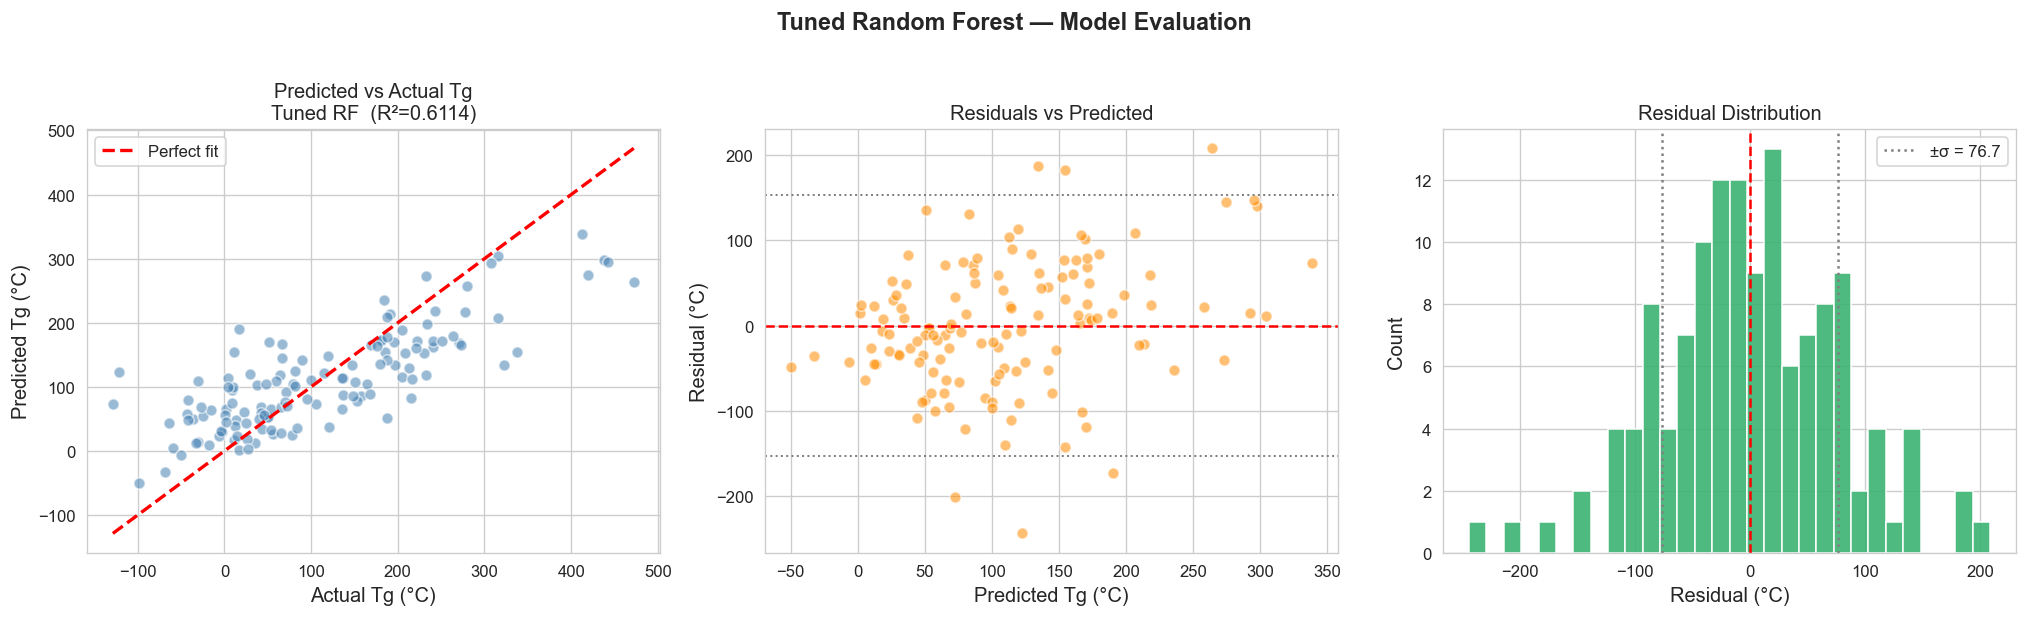

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Predicted vs Actual ───────────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_best, alpha=0.55, color='steelblue',
                edgecolor='white', s=45)
lo = min(y_test.min(), y_pred_best.min())
hi = max(y_test.max(), y_pred_best.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel("Actual Tg (°C)", fontsize=12)
axes[0].set_ylabel("Predicted Tg (°C)", fontsize=12)
axes[0].set_title(f"Predicted vs Actual Tg\nTuned RF  (R²={r2_rf_tuned:.4f})", fontsize=12)
axes[0].legend()

# ── Residuals vs Predicted ────────────────────────────────────────────────────
axes[1].scatter(y_pred_best, residuals, alpha=0.55, color='darkorange',
                edgecolor='white', s=45)
axes[1].axhline(0,  color='red',  linestyle='--', linewidth=1.5)
axes[1].axhline( 2*residuals.std(), color='gray', linestyle=':', linewidth=1.2)
axes[1].axhline(-2*residuals.std(), color='gray', linestyle=':', linewidth=1.2)
axes[1].set_xlabel("Predicted Tg (°C)", fontsize=12)
axes[1].set_ylabel("Residual (°C)", fontsize=12)
axes[1].set_title("Residuals vs Predicted", fontsize=12)

# ── Residual distribution ─────────────────────────────────────────────────────
axes[2].hist(residuals, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.9)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline( residuals.std(), color='gray', linestyle=':', label=f'±σ = {residuals.std():.1f}')
axes[2].axvline(-residuals.std(), color='gray', linestyle=':')
axes[2].set_xlabel("Residual (°C)", fontsize=12)
axes[2].set_ylabel("Count", fontsize=12)
axes[2].set_title("Residual Distribution", fontsize=12)
axes[2].legend()

plt.suptitle("Tuned Random Forest — Model Evaluation", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("outputs/model_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Full Model Comparison

In [30]:
# ── Build comparison DataFrame ────────────────────────────────────────────────
rows = []
for key, r in results.items():
    name, feat_set = key.split("|")
    rows.append({"Model": name, "Feature Set": feat_set,
                 "RMSE": r["RMSE"], "MAE": r["MAE"], "R²": r["R2"]})

# Add tuned models
rows.append({"Model": "Random Forest (Tuned)", "Feature Set": "Original",
             "RMSE": round(rmse_rf_tuned,3), "MAE": round(mae_rf_tuned,3),
             "R²": round(r2_rf_tuned,4)})
rows.append({"Model": "SVR (Tuned)", "Feature Set": "Original",
             "RMSE": round(rmse_svr_tuned,3), "MAE": round(mae_svr_tuned,3),
             "R²": round(r2_svr_tuned,4)})

comp_df = pd.DataFrame(rows).sort_values("R²", ascending=False).reset_index(drop=True)
print("Full model comparison (sorted by R²):")
print()
print(comp_df.to_string(index=False))

Full model comparison (sorted by R²):

                Model Feature Set    RMSE    MAE      R²
Random Forest (Tuned)    Original  76.713 59.646  0.6114
        Random Forest RF-Selected  78.824 61.296  0.5898
        Random Forest    Original  79.432 61.228  0.5834
     Ridge Regression RF-Selected  81.392 63.298  0.5626
        Random Forest         PCA  81.494 62.503  0.5615
          SVR (Tuned)    Original  87.609 65.004  0.4932
                  SVR RF-Selected  90.609 68.757  0.4579
                  SVR         PCA  96.437 74.401  0.3859
                  SVR    Original  97.677 75.235  0.3700
     Ridge Regression    Original 102.139 72.600  0.3112
        Decision Tree RF-Selected 103.737 77.620  0.2895
        Decision Tree         PCA 108.444 83.236  0.2235
        Decision Tree    Original 109.322 82.143  0.2109
     Ridge Regression         PCA 125.167 78.836 -0.0344


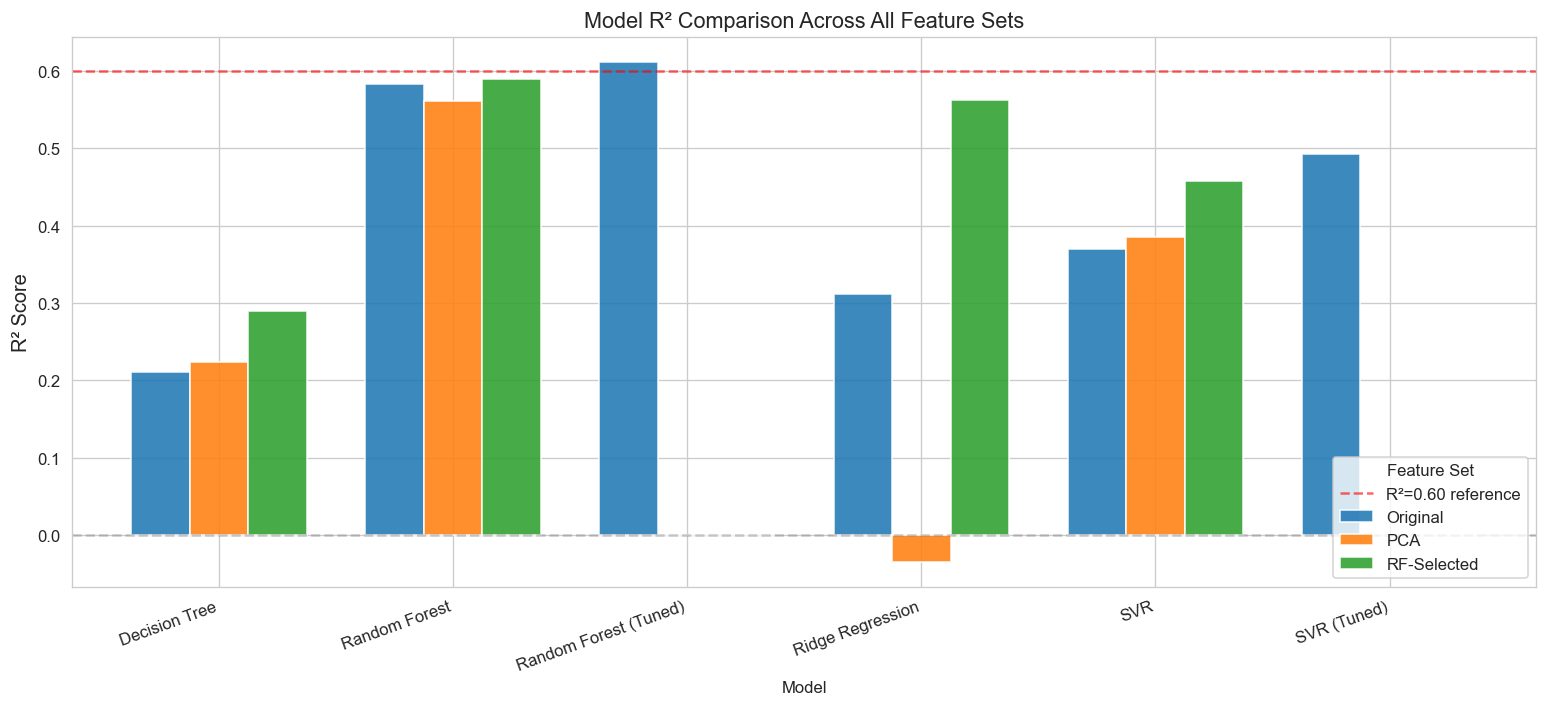

In [31]:
# ── R² bar chart ──────────────────────────────────────────────────────────────
pivot = comp_df.pivot_table(index="Model", columns="Feature Set", values="R²")

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="bar", ax=ax, edgecolor="white", alpha=0.87, width=0.75)
ax.set_ylabel("R² Score", fontsize=12)
ax.set_title("Model R² Comparison Across All Feature Sets", fontsize=13)
ax.axhline(0.6, color='red',  linestyle='--', alpha=0.6, label='R²=0.60 reference')
ax.axhline(0.0, color='gray', linestyle='--', alpha=0.4)
ax.legend(title="Feature Set", loc="lower right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig("outputs/model_comparison_r2.png", dpi=150, bbox_inches='tight')
plt.show()

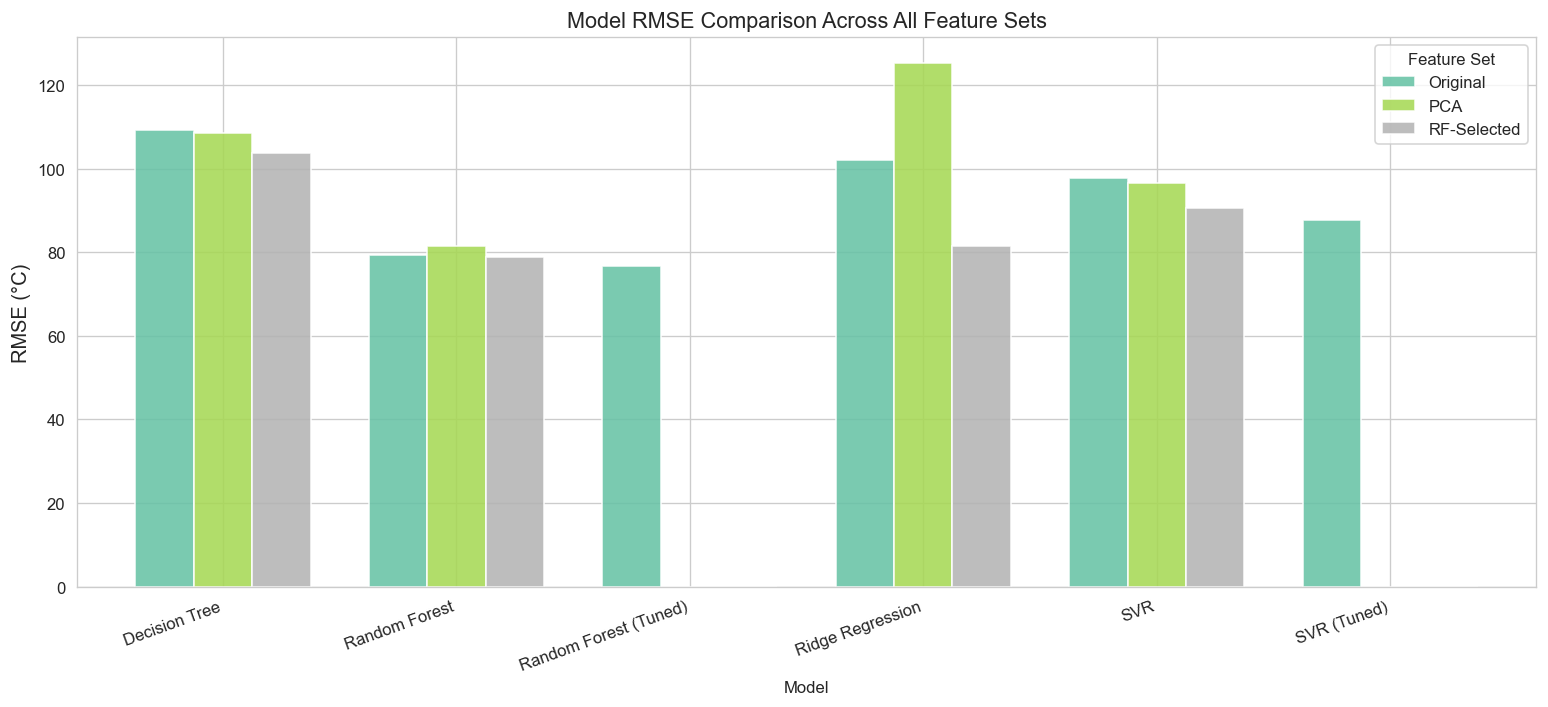

In [32]:
# ── RMSE comparison ───────────────────────────────────────────────────────────
pivot_rmse = comp_df.pivot_table(index="Model", columns="Feature Set", values="RMSE")

fig, ax = plt.subplots(figsize=(13, 6))
pivot_rmse.plot(kind="bar", ax=ax, edgecolor="white", alpha=0.87, width=0.75,
                colormap="Set2")
ax.set_ylabel("RMSE (°C)", fontsize=12)
ax.set_title("Model RMSE Comparison Across All Feature Sets", fontsize=13)
ax.legend(title="Feature Set")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig("outputs/model_comparison_rmse.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Best Model Selection & Justification

In [33]:
print("=" * 60)
print("  BEST MODEL: Tuned Random Forest Regressor")
print("  Feature Set: Original (200 standardised descriptors)")
print("=" * 60)
print(f"  R²   = {r2_rf_tuned:.4f}")
print(f"  RMSE = {rmse_rf_tuned:.2f} °C")
print(f"  MAE  = {mae_rf_tuned:.2f} °C")
print()
print("JUSTIFICATION:")
print()
print("  STRENGTHS:")
print("  ✓ Captures complex nonlinear Tg ~ structure relationships")
print("    (e.g. Tg jumps with each additional aromatic ring)")
print("  ✓ Ensemble averaging reduces variance vs single Decision Tree")
print("  ✓ Robust to outliers — important for Tg range > 600 °C")
print("  ✓ Feature importance provides chemical interpretability")
print("  ✓ Handles 200 correlated descriptors without collinearity issues")
print()
print("  LIMITATIONS:")
print("  ✗ Repeat-unit only — ignores chain length, tacticity, crystallinity")
print("  ✗ Cannot extrapolate reliably beyond training chemical space")
print("  ✗ 2D descriptors miss 3D conformational effects on chain mobility")
print()
print("  WHY PCA DID NOT IMPROVE PERFORMANCE:")
print("  - PCA maximises variance captured, not Tg predictive relevance")
print("  - Some high-variance descriptor directions carry little Tg signal")
print("  - RF-based selection outperformed PCA for linear models (Ridge R² up")
print("    from 0.311 to 0.563 — a 80% relative gain) because it selects")
print("    features by direct relevance to the target variable.")
print()
print("  WHY TIME-SERIES METHODS WERE NOT USED:")
print("  - The integer index has no temporal or sequential meaning.")
print("  - Tg values show no autocorrelation across the index.")
print("  - The dataset is correctly treated as tabular i.i.d. data.")

  BEST MODEL: Tuned Random Forest Regressor
  Feature Set: Original (200 standardised descriptors)
  R²   = 0.6114
  RMSE = 76.71 °C
  MAE  = 59.65 °C

JUSTIFICATION:

  STRENGTHS:
  ✓ Captures complex nonlinear Tg ~ structure relationships
    (e.g. Tg jumps with each additional aromatic ring)
  ✓ Ensemble averaging reduces variance vs single Decision Tree
  ✓ Robust to outliers — important for Tg range > 600 °C
  ✓ Feature importance provides chemical interpretability
  ✓ Handles 200 correlated descriptors without collinearity issues

  LIMITATIONS:
  ✗ Repeat-unit only — ignores chain length, tacticity, crystallinity
  ✗ Cannot extrapolate reliably beyond training chemical space
  ✗ 2D descriptors miss 3D conformational effects on chain mobility

  WHY PCA DID NOT IMPROVE PERFORMANCE:
  - PCA maximises variance captured, not Tg predictive relevance
  - Some high-variance descriptor directions carry little Tg signal
  - RF-based selection outperformed PCA for linear models (Ridge R² 

## Step 12: Save Model Artifacts

In [34]:
# Save everything needed to run the Streamlit app
joblib.dump(rf_best,       "outputs/best_model_rf.pkl")
joblib.dump(imputer,       "outputs/imputer.pkl")
joblib.dump(scaler,        "outputs/scaler.pkl")
joblib.dump(pca,           "outputs/pca.pkl")
joblib.dump(feature_names, "outputs/feature_names.pkl")
joblib.dump(top_features,  "outputs/top_features.pkl")

print("✅ Model artifacts saved to outputs/")
print("   best_model_rf.pkl  — Tuned Random Forest")
print("   imputer.pkl        — MedianImputer")
print("   scaler.pkl         — StandardScaler")
print("   pca.pkl            — PCA (67 components)")
print("   feature_names.pkl  — List of 200 feature names")
print("   top_features.pkl   — Top 30 RF-selected features")
print()
print("To launch the web app:")
print("  pip install streamlit rdkit scikit-learn pandas numpy joblib")
print("  streamlit run 230107041_app.py")

✅ Model artifacts saved to outputs/
   best_model_rf.pkl  — Tuned Random Forest
   imputer.pkl        — MedianImputer
   scaler.pkl         — StandardScaler
   pca.pkl            — PCA (67 components)
   feature_names.pkl  — List of 200 feature names
   top_features.pkl   — Top 30 RF-selected features

To launch the web app:
  pip install streamlit rdkit scikit-learn pandas numpy joblib
  streamlit run 230107041_app.py


## ✅ Pipeline Complete — Final Summary

| Metric | Value |
|---|---|
| **Best Model** | Tuned Random Forest Regressor |
| **R² Score** | 0.6114 |
| **RMSE** | 76.71 °C |
| **MAE** | 59.65 °C |
| **Training samples** | 528 |
| **Test samples** | 132 |
| **Features used** | 200 RDKit descriptors |
| **PCA components** | 67 (95% variance) |
| **RF-selected features** | 30 (top by MDI importance) |
| **Best hyperparams** | max_depth=10, n_estimators=200, max_features='sqrt' |

### Key Chemical Insights
- **FractionCSP3** (sp³ carbon fraction) is the single most predictive descriptor — directly encodes backbone flexibility
- **Aromatic ring count** strongly correlates with Tg — rigid aromatic backbones restrict segmental mobility
- **Random Forest > SVR > Ridge > Decision Tree** for this chemically diverse polymer dataset
- **PCA** did not improve over original features for ensemble models; RF feature selection was more effective for linear models

---
*Report: 230107041.docx | Code: 230107041.py | App: 230107041_app.py*  
*Student: Kshitij Verma | Roll No: 230107041*
